# Deadlock-Aware Adaptive Switching for Multi-Agent Pathfinding
**Advanced Topics in AI — Afeka Tel Aviv Academic College of Engineering**

Roei Aviv (314753427) · Omer Ben Simon (323023010)

Agents must reach their goals on a shared grid under **partial observability** (an 11×11 window, no global map, no central controller). Building on the *When to Switch* framework (Skrynnik et al., IEEE TNNLS 2024) that alternates between classical planning (A\*) and reinforcement learning, we add a third mode — **intelligent deadlock escape** — and an **adaptive switching controller** that picks between the three per agent, per step:

| situation (per agent, per step) | mode |
|---|---|
| no progress over a sliding window (frozen / oscillating) | **Escape** — obstacle- and agent-aware move away from the conflict |
| other agents visible in the field of view | **RL** — PPO trained specifically on multi-agent interference |
| otherwise | **A\*** — optimal and cheap on the agent's accumulated memory map |

**Pipeline:** ① install → ② mount Drive → ③ write project modules → ④ run 17 unit tests → ⑤ train (resumable, safe against Colab disconnects) → ⑥ evaluate 5 configurations on paired instances + observation-radius sweep → ⑦ view results.

> ⚠️ Use a **GPU runtime** (Runtime → Change runtime type → T4 GPU).

## 1 · Install dependencies
Run once, then **Restart Session** (Runtime → Restart session) — required for the numpy downgrade — and continue from the next cell.

In [ ]:
%pip install "numpy<2.0" "pydantic<2.0" "gymnasium==0.28.1" pytest --quiet
%pip install pogema --quiet --no-build-isolation
print("DONE — now: Runtime → Restart session, then run the next cells.")

## 2 · Google Drive + project directory
Checkpoints, logs and results are stored on Drive so nothing is lost if Colab disconnects.

In [1]:
import os

try:                                   # Colab
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    PROJECT = '/content/mapf_project'
except ImportError:                    # local run: anchor to the notebook's own folder
    nb_path = globals().get('__vsc_ipynb_file__')      # set by VS Code
    PROJECT = os.path.dirname(nb_path) if nb_path else os.getcwd()

os.makedirs(f'{PROJECT}/mapf', exist_ok=True)
os.makedirs(f'{PROJECT}/tests', exist_ok=True)
%cd {PROJECT}

import torch, pogema, numpy
print(f"torch {torch.__version__} | cuda: {torch.cuda.is_available()} | "
      f"pogema {pogema.__version__} | numpy {numpy.__version__}")


/Users/bentzi/Downloads/mapf_project


torch 2.12.0 | cuda: False | pogema 1.4.0 | numpy 1.26.4


## 3 · Project modules
Written as proper Python modules (rather than one monolithic script) for readability, reuse and testability. Every fix is documented in the module docstrings:

* `mapf/env.py` — environment wrapper: aligned 4-channel observations, distance-progress reward, finish-and-vanish goal semantics, randomized move order, per-agent **global** obstacle memory + visited map.
* `mapf/model.py` — Actor-Critic CNN; `AdaptiveAvgPool2d` makes it **radius-agnostic**.
* `mapf/planners.py` — A\* on partial maps, deadlock monitor, smart escape, and the five policies including the **switching controller**.
* `mapf/ppo.py` — PPO + GAE with proper truncation bootstrapping and minibatch updates.
* `train.py` / `evaluate.py` — resumable training and standalone evaluation.
* `tests/test_mapf.py` — 17 unit tests on deterministic POGEMA instances.

In [ ]:
%%writefile mapf/__init__.py
"""Deadlock-Aware Adaptive Switching for Multi-Agent Pathfinding."""

from .env import MAPFEnv, MOVES, manhattan            # noqa: F401
from .model import ActorCritic                        # noqa: F401
from .planners import (AStarPolicy, DeadlockMonitor,  # noqa: F401
                       EscapePolicy, RLPolicy, SwitchingPolicy, a_star,
                       escape_action)
from .ppo import PPOTrainer, compute_gae              # noqa: F401


In [ ]:
%%writefile mapf/env.py
"""POGEMA-based Multi-Agent Pathfinding environment wrapper.

This wrapper builds on ``pogema.grid.Grid`` (POGEMA 1.4.0) and fixes several
issues found in the first version of this project:

1. **Reward** -- the old ``+0.05 if target visible`` bonus fired on *every*
   step because POGEMA projects (clamps) the target onto the border of the
   observation window when it is out of range.  The net per-step reward was
   therefore positive (+0.04), which paid agents for wandering instead of
   finishing.  It is replaced with distance-progress shaping (see
   :meth:`MAPFEnv._reward`).

2. **Agents channel** -- the old code built the "nearby agents" channel with
   swapped row/column indices (transposed w.r.t. the obstacle and target
   channels).  We now use ``Grid.get_positions`` which is natively aligned
   with the POGEMA ``[dx, dy]`` convention.

3. **Goal semantics** -- agents that reach their goal are now *removed* from
   the map via ``Grid.hide_agent`` (POGEMA ``on_target='finish'`` semantics).
   Previously they stayed on their goal cells forever and acted as walls,
   artificially inflating deadlocks.

4. **Move order** -- agents move in a *randomized* order every step instead of
   always index 0 first, removing a systematic priority bias of the
   sequential ``Grid.move`` API.

5. **Memory** -- the old per-agent memory was a single local window that was
   element-wise ``max``-ed with observations taken at *different* world
   positions, i.e. meaningless superposition.  We now maintain, per agent:

   * a **global obstacle-memory map** (everything the agent has ever seen,
     written at world coordinates) -- used by the A* planner, *not* fed to
     the network;
   * a **global visited map** (cells the agent has stood on) whose *local
     slice* is fed to the network as channel 3, giving the policy an
     anti-looping signal that is meaningful inside the local window.

Observation per agent: ``float32 (4, 2r+1, 2r+1)`` with POGEMA convention
``[delta_row(=dx), delta_col(=dy)]``:

* ``0`` obstacles in field of view (1 = obstacle, includes border padding),
* ``1`` projected target (single cell, clamped to the window border when the
  goal is out of range),
* ``2`` other visible agents (self excluded),
* ``3`` visited cells inside the field of view.
"""

from __future__ import annotations

import numpy as np
from pogema import GridConfig
from pogema.grid import Grid

#: POGEMA action semantics: 0 stay, 1 up (-row), 2 down (+row), 3 left, 4 right.
MOVES = ((0, 0), (-1, 0), (1, 0), (0, -1), (0, 1))
DELTA_TO_ACTION = {d: a for a, d in enumerate(MOVES)}


def manhattan(a, b):
    """Manhattan (L1) distance between two ``(row, col)`` cells."""
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


class MAPFEnv:
    """Partially-observable multi-agent grid environment.

    Parameters
    ----------
    grid_kwargs:
        Keyword arguments forwarded to :class:`pogema.GridConfig`
        (``num_agents``, ``size``, ``density``, ``obs_radius``,
        ``max_episode_steps``, or ``map``/``agents_xy``/``targets_xy`` for
        deterministic instances).
    """

    #: reward constants (documented in the module docstring / paper)
    R_GOAL = 5.0          # terminal reward for reaching the goal
    R_STEP = -0.01        # per-step time cost
    R_PROGRESS = 0.05     # x (previous distance - new distance) to *true* goal
    R_BLOCKED = -0.05     # movement action attempted but the agent did not move

    def __init__(self, **grid_kwargs):
        self.grid_kwargs = dict(grid_kwargs)
        self.max_steps = int(self.grid_kwargs.get("max_episode_steps", 256))
        self.grid: Grid | None = None
        self.steps = 0
        self.rng = np.random.default_rng()
        # per-agent global maps, created in reset()
        self.memory: list[np.ndarray] = []    # known obstacles (planner)
        self.visited: list[np.ndarray] = []   # visited cells (net channel 3)
        self._done: list[bool] = []

    # ------------------------------------------------------------------ #
    # episode control
    # ------------------------------------------------------------------ #
    def reset(self, seed: int | None = None):
        """Start a new episode; returns ``(observations, info)``."""
        if seed is None:
            seed = int(self.rng.integers(0, 1_000_000))
        # reseed the dynamics RNG (move order) from the episode seed so that
        # paired-seed evaluations share identical dynamics and reruns are
        # reproducible, not just map-paired
        self.rng = np.random.default_rng(seed)
        cfg = GridConfig(seed=seed, **self.grid_kwargs)
        self.grid = Grid(cfg)
        self.config = cfg
        self.steps = 0
        na = cfg.num_agents
        full_shape = self.grid.obstacles.shape  # padded (size+2r, size+2r)
        self.memory = [np.zeros(full_shape, dtype=np.float32) for _ in range(na)]
        self.visited = [np.zeros(full_shape, dtype=np.float32) for _ in range(na)]
        self._done = [False] * na
        for i in range(na):
            self._sense(i)
        return [self._obs(i) for i in range(na)], {"seed": seed}

    @property
    def num_agents(self) -> int:
        return self.config.num_agents

    def active(self, i: int) -> bool:
        return not self._done[i]

    # ------------------------------------------------------------------ #
    # observation helpers (also used by the planners)
    # ------------------------------------------------------------------ #
    def agent_position(self, i):
        """Current ``(row, col)`` of agent *i* in padded map coordinates."""
        return tuple(self.grid.positions_xy[i])

    def agent_goal(self, i):
        """Goal ``(row, col)`` of agent *i* (agents always know their own goal)."""
        return tuple(self.grid.finishes_xy[i])

    def known_obstacles(self, i) -> np.ndarray:
        """Agent *i*'s accumulated obstacle map (1 = seen obstacle)."""
        return self.memory[i]

    def visible_agent_cells(self, i):
        """World coordinates of *other* agents currently inside *i*'s FOV."""
        r = self.config.obs_radius
        window = self.grid.get_positions(i)
        x, y = self.agent_position(i)
        cells = set()
        for wx, wy in np.argwhere(window > 0):
            if wx == r and wy == r:      # skip self at the window center
                continue
            cells.add((x - r + int(wx), y - r + int(wy)))
        return cells

    def _sense(self, i):
        """Write the current ground-truth FOV into agent *i*'s global maps."""
        r = self.config.obs_radius
        x, y = self.agent_position(i)
        window = self.grid.get_obstacles_for_agent(i)
        # observations are ground truth for the window -> plain assignment
        self.memory[i][x - r:x + r + 1, y - r:y + r + 1] = window
        self.visited[i][x, y] = 1.0

    def _obs(self, i) -> np.ndarray:
        """4-channel observation for agent *i* (zeros once the agent is done)."""
        r = self.config.obs_radius
        s = 2 * r + 1
        if self._done[i]:
            return np.zeros((4, s, s), dtype=np.float32)
        obstacles = self.grid.get_obstacles_for_agent(i)
        target = self.grid.get_square_target(i)
        agents = self.grid.get_positions(i).copy()
        agents[r, r] = 0.0                       # exclude self
        x, y = self.agent_position(i)
        visited = self.visited[i][x - r:x + r + 1, y - r:y + r + 1]
        return np.stack([obstacles, target, agents, visited]).astype(np.float32)

    # ------------------------------------------------------------------ #
    # dynamics
    # ------------------------------------------------------------------ #
    def step(self, actions):
        """Advance one time step.

        Returns ``(obs, rewards, terminated, truncated, info)`` where the
        ``terminated[i]`` flag is True only on the step agent *i* reaches its
        goal, and ``truncated[i]`` is True for agents still active when the
        step limit is hit.
        """
        assert self.grid is not None, "call reset() first"
        self.steps += 1
        na = self.num_agents
        rewards = [0.0] * na
        terminated = [False] * na
        truncated = [False] * na
        blocked = [False] * na

        order = self.rng.permutation(na)         # fix #4: no index priority
        for i in order:
            i = int(i)
            if self._done[i]:
                continue
            pos_before = self.agent_position(i)
            goal = self.agent_goal(i)
            d_before = manhattan(pos_before, goal)
            action = int(actions[i])
            self.grid.move(i, action)
            pos_after = self.agent_position(i)
            blocked[i] = action != 0 and pos_after == pos_before

            if pos_after == goal:                # fix #3: finish-and-vanish
                rewards[i] = self.R_GOAL
                terminated[i] = True
                self._done[i] = True
                self.grid.hide_agent(i)
                continue

            d_after = manhattan(pos_after, goal)
            rewards[i] = (self.R_STEP
                          + self.R_PROGRESS * (d_before - d_after)
                          + (self.R_BLOCKED if blocked[i] else 0.0))

        hit_limit = self.steps >= self.max_steps
        for i in range(na):
            if self._done[i]:
                continue
            self._sense(i)
            if hit_limit:
                truncated[i] = True
                self._done[i] = True

        obs = [self._obs(i) for i in range(na)]
        info = {"blocked": blocked,
                "positions": [self.agent_position(i) for i in range(na)]}
        return obs, rewards, terminated, truncated, info

    def all_done(self) -> bool:
        return all(self._done)


In [ ]:
%%writefile mapf/model.py
"""Actor-Critic network for the PPO agent.

The convolutional trunk ends with ``AdaptiveAvgPool2d``, which makes the
network *independent of the observation radius*: a model trained with
``obs_radius=5`` (11x11 windows) can be evaluated zero-shot with radius 3 or 7
windows.  This supports the paper's second research axis ("how much the agents
see") without training a separate network per radius.
"""

from __future__ import annotations

import torch
import torch.nn as nn


class RadiusAgnosticPool(nn.Module):
    """Drop-in replacement for ``nn.AdaptiveAvgPool2d`` computing the exact
    same output (identical bin boundaries), expressed as two matmuls.

    Needed because the native MPS kernel rejects input sizes that are not
    divisible by the output size (pytorch#96056), e.g. 11x11 -> 5x5.
    Parameter-free, so checkpoints stay interchangeable with models built
    with ``nn.AdaptiveAvgPool2d``.
    """

    def __init__(self, output_size):
        super().__init__()
        self.out_h, self.out_w = output_size
        self._cache = {}

    @staticmethod
    def _weights(in_size, out_size, device, dtype):
        w = torch.zeros(out_size, in_size, device=device, dtype=dtype)
        for i in range(out_size):
            lo = (i * in_size) // out_size
            hi = -((-(i + 1) * in_size) // out_size)
            w[i, lo:hi] = 1.0 / (hi - lo)
        return w

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h, w = x.shape[-2:]
        key = (h, w, x.device, x.dtype)
        if key not in self._cache:
            self._cache[key] = (
                self._weights(h, self.out_h, x.device, x.dtype),
                self._weights(w, self.out_w, x.device, x.dtype))
        rows, cols = self._cache[key]
        return rows @ x @ cols.T


class ActorCritic(nn.Module):
    """Shared conv trunk with separate policy (actor) and value (critic) heads.

    Parameters
    ----------
    in_channels:
        Number of observation channels (4: obstacles / target / agents /
        visited -- see :mod:`mapf.env`).
    n_actions:
        Size of the discrete action space (5 in POGEMA).
    """

    def __init__(self, in_channels: int = 4, n_actions: int = 5):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(),
            RadiusAgnosticPool((5, 5)),          # radius-agnostic
            nn.Flatten(),
            nn.Linear(64 * 5 * 5, 256), nn.ReLU(),
        )
        self.actor = nn.Linear(256, n_actions)
        self.critic = nn.Linear(256, 1)

    def forward(self, x: torch.Tensor):
        """Returns ``(logits [B, n_actions], value [B])``."""
        features = self.trunk(x)
        return self.actor(features), self.critic(features).squeeze(-1)

    @torch.no_grad()
    def act_greedy(self, obs_batch: torch.Tensor) -> torch.Tensor:
        """Deterministic (argmax) actions for evaluation."""
        logits, _ = self(obs_batch)
        return logits.argmax(dim=-1)


In [ ]:
%%writefile mapf/planners.py
"""Planning, deadlock escape, and the Deadlock-Aware Adaptive Switching policy.

Five evaluated configurations, all sharing the same ``select_actions``
interface:

* :class:`AStarPolicy`            -- planning only,
* :class:`EscapePolicy` (A*)      -- planning + smart escape,
* :class:`RLPolicy`               -- learned policy only,
* :class:`EscapePolicy` (RL)      -- learned policy + smart escape,
* :class:`SwitchingPolicy`        -- **our contribution**: deadlock-aware
  adaptive switching between A*, RL and escape.

Partial observability is respected everywhere: the planner of agent *i* uses
only (a) agent *i*'s accumulated obstacle memory, (b) agent *i*'s own goal
coordinate (agents always know their own goal in POGEMA), and (c) other agents
*currently visible* in agent *i*'s field of view.  No global information is
shared between agents.
"""

from __future__ import annotations

import heapq
from collections import deque

import numpy as np

from .env import DELTA_TO_ACTION, MOVES, manhattan

# --------------------------------------------------------------------------- #
# A* on the agent's accumulated memory map
# --------------------------------------------------------------------------- #


def a_star(known_obstacles: np.ndarray, start, goal,
           blocked=frozenset(), max_expansions: int = 20_000):
    """A* over a partially known grid.

    Unobserved cells are treated as free (optimistic assumption, standard for
    navigation under partial observability); ``blocked`` adds temporary
    obstacles (currently visible agents).  The goal cell is never treated as
    blocked.  Returns the path ``[start, ..., goal]`` or ``None``.
    """
    if start == goal:
        return [start]
    h, w = known_obstacles.shape
    open_heap = [(manhattan(start, goal), 0, start)]
    g_cost = {start: 0}
    parent = {}
    expansions = 0
    while open_heap and expansions < max_expansions:
        _, g, cell = heapq.heappop(open_heap)
        if cell == goal:
            path = [cell]
            while cell in parent:
                cell = parent[cell]
                path.append(cell)
            return path[::-1]
        if g > g_cost.get(cell, float("inf")):
            continue                       # stale heap entry
        expansions += 1
        for dx, dy in MOVES[1:]:
            nxt = (cell[0] + dx, cell[1] + dy)
            if not (0 <= nxt[0] < h and 0 <= nxt[1] < w):
                continue
            if known_obstacles[nxt] == 1 or (nxt in blocked and nxt != goal):
                continue
            ng = g + 1
            if ng < g_cost.get(nxt, float("inf")):
                g_cost[nxt] = ng
                parent[nxt] = cell
                heapq.heappush(open_heap, (ng + manhattan(nxt, goal), ng, nxt))
    return None


# --------------------------------------------------------------------------- #
# deadlock detection + escape
# --------------------------------------------------------------------------- #


class DeadlockMonitor:
    """Detects agents that stopped making progress.

    An agent is considered deadlocked when its last ``window`` positions
    contain at most two distinct cells -- this catches both frozen agents and
    two-cell oscillations (livelocks).  When triggered, the agent enters
    escape mode for ``escape_steps`` steps and its history is cleared so the
    trigger does not re-fire immediately.
    """

    def __init__(self, num_agents: int, window: int = 4, escape_steps: int = 3):
        self.window = window
        self.escape_steps = escape_steps
        self.history = [deque(maxlen=window) for _ in range(num_agents)]
        self.countdown = [0] * num_agents

    def in_escape(self, i: int, position) -> bool:
        """Update agent *i* with its current position; True while escaping."""
        if self.countdown[i] > 0:
            self.countdown[i] -= 1
            return True
        self.history[i].append(position)
        if (len(self.history[i]) == self.window
                and len(set(self.history[i])) <= 2):
            self.countdown[i] = self.escape_steps - 1
            self.history[i].clear()
            return True
        return False


def escape_action(obs: np.ndarray, rng: np.random.Generator,
                  previous_position=None, current_position=None) -> int:
    """Pick a random *safe* direction to break a deadlock.

    A direction is safe when the neighbouring cell is neither an obstacle
    (channel 0) nor occupied by a visible agent (channel 2).  Stepping back to
    ``previous_position`` is avoided when an alternative exists, so escape
    actually leaves the conflict area instead of bouncing.
    """
    c = obs.shape[-1] // 2
    options = []
    for action, (dx, dy) in enumerate(MOVES):
        if action == 0:
            continue
        if obs[0][c + dx, c + dy] == 0 and obs[2][c + dx, c + dy] == 0:
            options.append(action)
    if previous_position is not None and current_position is not None and len(options) > 1:
        back = (previous_position[0] - current_position[0],
                previous_position[1] - current_position[1])
        back_action = DELTA_TO_ACTION.get(back)
        options = [a for a in options if a != back_action] or options
    return int(rng.choice(options)) if options else 0


# --------------------------------------------------------------------------- #
# policies (shared interface: select_actions(env, obs) -> list[int])
# --------------------------------------------------------------------------- #


class AStarPolicy:
    """Plan with A* on the agent's memory map; replan lazily.

    A cached path is reused until (a) the agent deviated from it, (b) the next
    cell is blocked by a known obstacle or a visible agent, or (c)
    ``replan_every`` steps elapsed (new observations may have revealed a
    better route).
    """

    name = "A* Only"

    def __init__(self, env, replan_every: int = 8, seed: int = 0):
        self.env = env
        self.replan_every = replan_every
        self.rng = np.random.default_rng(seed)
        self.reset()

    def reset(self):
        self.paths = {}
        self.age = {}

    def _action_for(self, i: int, obs_i: np.ndarray) -> int:
        env = self.env
        pos, goal = env.agent_position(i), env.agent_goal(i)
        visible = env.visible_agent_cells(i)
        path = self.paths.get(i)
        self.age[i] = self.age.get(i, 0) + 1
        stale = (not path or pos not in path
                 or self.age[i] % self.replan_every == 0)
        if not stale:
            nxt = path[path.index(pos) + 1] if path.index(pos) + 1 < len(path) else None
            stale = (nxt is None or nxt in visible
                     or env.known_obstacles(i)[nxt] == 1)
        if stale:
            path = a_star(env.known_obstacles(i), pos, goal, blocked=visible)
            self.paths[i] = path
        if not path or pos not in path or path.index(pos) + 1 >= len(path):
            # fully enclosed by known obstacles / agents: nudge randomly
            return escape_action(obs_i, self.rng, current_position=pos)
        nxt = path[path.index(pos) + 1]
        return DELTA_TO_ACTION[(nxt[0] - pos[0], nxt[1] - pos[1])]

    def select_actions(self, env, obs):
        return [self._action_for(i, obs[i]) if env.active(i) else 0
                for i in range(env.num_agents)]


class RLPolicy:
    """Actions from a trained :class:`~mapf.model.ActorCritic`.

    ``stochastic=False`` (default) takes the argmax action.  With
    ``stochastic=True`` actions are *sampled* from the policy distribution --
    the regime the network was actually trained in; greedy evaluation of a
    stochastically-trained policy can lock into oscillations that sampling
    breaks.  Sampling uses a seeded CPU generator so paired-seed evaluation
    stays reproducible on any device.
    """

    name = "RL Only"

    def __init__(self, model, device, stochastic: bool = False, seed: int = 0):
        import torch
        self.torch = torch
        self.model = model.to(device).eval()
        self.device = device
        self.stochastic = stochastic
        if stochastic:
            self.name = "RL Only (sampled)"
            self.gen = torch.Generator().manual_seed(seed)

    def reset(self):
        pass

    def actions_for(self, obs_subset):
        """Batched actions for a list of observations."""
        if not obs_subset:
            return []
        batch = self.torch.as_tensor(np.stack(obs_subset),
                                     dtype=self.torch.float32,
                                     device=self.device)
        if not self.stochastic:
            return self.model.act_greedy(batch).cpu().tolist()
        with self.torch.no_grad():
            logits, _ = self.model(batch)
        probs = self.torch.softmax(logits, dim=-1).cpu()
        return self.torch.multinomial(probs, 1,
                                      generator=self.gen).squeeze(-1).tolist()

    def select_actions(self, env, obs):
        idx = [i for i in range(env.num_agents) if env.active(i)]
        acts = self.actions_for([obs[i] for i in idx])
        out = [0] * env.num_agents
        for i, a in zip(idx, acts):
            out[i] = a
        return out


class RandomPolicy:
    """Uniform-random movement policy.

    Used as an ablation drop-in for the RL slot of
    :class:`SwitchingPolicy`, answering "is the learned policy load-bearing,
    or does the A*/escape scaffold do all the work?".
    """

    name = "Random"

    def __init__(self, seed: int = 0):
        self.rng = np.random.default_rng(seed)

    def reset(self):
        pass

    def actions_for(self, obs_subset):
        return [int(a) for a in self.rng.integers(0, len(MOVES),
                                                  size=len(obs_subset))]

    def select_actions(self, env, obs):
        idx = [i for i in range(env.num_agents) if env.active(i)]
        acts = self.actions_for([obs[i] for i in idx])
        out = [0] * env.num_agents
        for i, a in zip(idx, acts):
            out[i] = a
        return out


class EscapePolicy:
    """Wrap any base policy with deadlock detection + smart escape."""

    def __init__(self, base, num_agents: int, window: int = 4,
                 escape_steps: int = 3, seed: int = 0):
        self.base = base
        self.name = base.name.replace(" Only", "") + " + Escape"
        self.monitor = DeadlockMonitor(num_agents, window, escape_steps)
        self.rng = np.random.default_rng(seed)
        self.prev_pos = [None] * num_agents

    def reset(self):
        self.base.reset()
        self.monitor = DeadlockMonitor(len(self.prev_pos),
                                       self.monitor.window,
                                       self.monitor.escape_steps)
        self.prev_pos = [None] * len(self.prev_pos)

    def select_actions(self, env, obs):
        base_actions = self.base.select_actions(env, obs)
        out = []
        for i in range(env.num_agents):
            if not env.active(i):
                out.append(0)
                continue
            pos = env.agent_position(i)
            if self.monitor.in_escape(i, pos):
                out.append(escape_action(obs[i], self.rng,
                                         self.prev_pos[i], pos))
            else:
                out.append(base_actions[i])
            self.prev_pos[i] = pos
        return out


class SwitchingPolicy:
    """Deadlock-Aware Adaptive Switching (our contribution).

    Per agent, per step:

    * **escape** when the :class:`DeadlockMonitor` fires -- neither planning
      nor learning resolves persistent deadlocks reliably;
    * **RL** when other agents are visible in the FOV -- the learned policy
      was trained specifically on multi-agent interference;
    * **A*** otherwise -- optimal and cheap when navigating alone on the
      accumulated map.

    Mode usage is counted in :attr:`mode_counts` and reported by the
    evaluation script.
    """

    name = "Switching (A*/RL) + Escape"

    def __init__(self, astar: AStarPolicy, rl: RLPolicy, num_agents: int,
                 window: int = 4, escape_steps: int = 3, seed: int = 0):
        self.astar = astar
        self.rl = rl
        self.monitor = DeadlockMonitor(num_agents, window, escape_steps)
        self.rng = np.random.default_rng(seed)
        self.prev_pos = [None] * num_agents
        self.mode_counts = {"astar": 0, "rl": 0, "escape": 0}

    def reset(self):
        self.astar.reset()
        self.monitor = DeadlockMonitor(len(self.prev_pos),
                                       self.monitor.window,
                                       self.monitor.escape_steps)
        self.prev_pos = [None] * len(self.prev_pos)

    def select_actions(self, env, obs):
        out = [0] * env.num_agents
        rl_agents = []
        for i in range(env.num_agents):
            if not env.active(i):
                continue
            pos = env.agent_position(i)
            if self.monitor.in_escape(i, pos):
                out[i] = escape_action(obs[i], self.rng, self.prev_pos[i], pos)
                self.mode_counts["escape"] += 1
            elif obs[i][2].sum() > 0:          # other agents in FOV
                rl_agents.append(i)
                self.mode_counts["rl"] += 1
            else:
                out[i] = self.astar._action_for(i, obs[i])
                self.mode_counts["astar"] += 1
            self.prev_pos[i] = pos
        for i, a in zip(rl_agents, self.rl.actions_for([obs[i] for i in rl_agents])):
            out[i] = a
        return out


In [ ]:
%%writefile mapf/ppo.py
"""PPO training utilities.

Fixes over the first version of the project:

* **Truncation bootstrap** -- when an episode is cut by the step limit the
  value of the final state is used to bootstrap the advantage estimate
  (previously truncation was treated like termination, biasing the critic).
* **Multi-episode buffer + minibatches** -- updates run on at least
  ``min_batch`` transitions with shuffled minibatches instead of one
  full-batch update per episode, which stabilises learning.
* Trajectories are stored per agent per episode, so GAE never has to mask
  intermediate ``done`` flags.
"""

from __future__ import annotations

import numpy as np
import torch
import torch.nn as nn


def compute_gae(rewards, values, gamma: float, lam: float,
                bootstrap_value: float = 0.0):
    """Generalised Advantage Estimation for one trajectory.

    ``bootstrap_value`` is ``V(s_T)`` when the trajectory was *truncated*
    and ``0`` when it properly *terminated*.
    Returns ``(returns, advantages)`` as float32 numpy arrays.
    """
    T = len(rewards)
    advantages = np.zeros(T, dtype=np.float32)
    g = 0.0
    for t in reversed(range(T)):
        next_value = values[t + 1] if t < T - 1 else bootstrap_value
        delta = rewards[t] + gamma * next_value - values[t]
        g = delta + gamma * lam * g
        advantages[t] = g
    returns = advantages + np.asarray(values, dtype=np.float32)
    return returns, advantages


class PPOTrainer:
    """Clipped-surrogate PPO with a simple trajectory buffer."""

    def __init__(self, model, device, lr: float = 3e-4, gamma: float = 0.99,
                 lam: float = 0.95, clip: float = 0.2, epochs: int = 4,
                 minibatch: int = 512, min_batch: int = 2048,
                 value_coef: float = 0.5, entropy_coef: float = 0.01,
                 max_grad_norm: float = 0.5):
        self.model = model.to(device)
        self.device = device
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        self.scheduler = torch.optim.lr_scheduler.StepLR(
            self.optimizer, step_size=300, gamma=0.7)
        self.gamma, self.lam, self.clip = gamma, lam, clip
        self.epochs, self.minibatch, self.min_batch = epochs, minibatch, min_batch
        self.value_coef, self.entropy_coef = value_coef, entropy_coef
        self.max_grad_norm = max_grad_norm
        self._buffer = []
        self._size = 0

    # ------------------------------------------------------------------ #
    def add_trajectory(self, obs, actions, log_probs, values, rewards,
                       truncated: bool, bootstrap_value: float):
        """Store one agent's episode trajectory."""
        if not rewards:
            return
        returns, advantages = compute_gae(
            rewards, values, self.gamma, self.lam,
            bootstrap_value if truncated else 0.0)
        self._buffer.append((np.asarray(obs, dtype=np.float32),
                             np.asarray(actions, dtype=np.int64),
                             np.asarray(log_probs, dtype=np.float32),
                             returns, advantages))
        self._size += len(rewards)

    def ready(self) -> bool:
        return self._size >= self.min_batch

    # ------------------------------------------------------------------ #
    def update(self):
        """Run PPO epochs over the buffered transitions; returns stats."""
        obs = torch.as_tensor(np.concatenate([b[0] for b in self._buffer]),
                              device=self.device)
        actions = torch.as_tensor(np.concatenate([b[1] for b in self._buffer]),
                                  device=self.device)
        old_logp = torch.as_tensor(np.concatenate([b[2] for b in self._buffer]),
                                   device=self.device)
        returns = torch.as_tensor(np.concatenate([b[3] for b in self._buffer]),
                                  device=self.device)
        adv = torch.as_tensor(np.concatenate([b[4] for b in self._buffer]),
                              device=self.device)
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        n = len(obs)
        # accumulate loss stats on-device; .item() per minibatch forces an
        # MPS pipeline sync between optimizer steps
        totals = torch.zeros(3, device=self.device)
        batches = 0
        for _ in range(self.epochs):
            for start in range(0, n, self.minibatch):
                idx = torch.randperm(n, device=self.device)[start:start + self.minibatch]
                logits, values = self.model(obs[idx])
                dist = torch.distributions.Categorical(logits=logits)
                logp = dist.log_prob(actions[idx])
                ratio = torch.exp(logp - old_logp[idx])
                surr1 = ratio * adv[idx]
                surr2 = torch.clamp(ratio, 1 - self.clip, 1 + self.clip) * adv[idx]
                policy_loss = -torch.min(surr1, surr2).mean()
                value_loss = nn.functional.mse_loss(values, returns[idx])
                entropy = dist.entropy().mean()
                loss = (policy_loss + self.value_coef * value_loss
                        - self.entropy_coef * entropy)
                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.model.parameters(),
                                         self.max_grad_norm)
                self.optimizer.step()
                totals += torch.stack([policy_loss.detach(),
                                       value_loss.detach(),
                                       entropy.detach()])
                batches += 1
        self.scheduler.step()
        self._buffer, self._size = [], 0
        policy_loss, value_loss, entropy = (totals / max(batches, 1)).cpu().tolist()
        return {"policy_loss": policy_loss, "value_loss": value_loss,
                "entropy": entropy}

    # ------------------------------------------------------------------ #
    def state_dict(self):
        return {"model": self.model.state_dict(),
                "optimizer": self.optimizer.state_dict(),
                "scheduler": self.scheduler.state_dict()}

    def load_state_dict(self, state):
        self.model.load_state_dict(state["model"])
        self.optimizer.load_state_dict(state["optimizer"])
        self.scheduler.load_state_dict(state["scheduler"])


In [ ]:
%%writefile train.py
"""Train the PPO agent (fully resumable -- safe against Colab disconnects).

All settings are environment variables so the script can be re-run across
several Colab sessions and simply continue where it stopped:

======================  =========================================  =========
variable                meaning                                    default
======================  =========================================  =========
``CKPT_DIR``            where checkpoints/logs are written          auto [*]
``MAX_HOURS``           wall-clock budget for *this* session        3.5
``TARGET_EPISODES``     stop after this many episodes (total)       8000
``AGENT_MIX``           agent counts sampled per episode            4,8,16
``MAP_SIZE``            grid size                                   32
``DENSITY``             obstacle density                            0.3
``OBS_RADIUS``          observation radius (window = 2r+1)          5
``MAX_STEPS``           episode step limit                          256
``SEED``                reproducible run: seeds weight init and
                        derives per-episode instance seeds from
                        (SEED, episode), stable across resumes       unset
======================  =========================================  =========

[*] ``/content/drive/MyDrive/RL_Project_Final`` when Google Drive is mounted,
otherwise ``./checkpoints``.

Checkpointing (fixes the old ``save()`` bug that overwrote the best weights
with the current ones every 30 minutes):

* ``checkpoint.pt``  -- full training state (model / optimizer / scheduler /
  episode counter / history / best score), written every 15 minutes and on
  exit; used to resume.
* ``best_model.pt``  -- model weights only, written **only** when the
  250-episode moving success rate improves.
"""

from __future__ import annotations

import json
import os
import time

import numpy as np
import torch

from mapf.env import MAPFEnv
from mapf.model import ActorCritic
from mapf.ppo import PPOTrainer


def default_ckpt_dir() -> str:
    drive = "/content/drive/MyDrive/RL_Project_Final"
    if os.path.isdir("/content/drive/MyDrive"):
        os.makedirs(drive, exist_ok=True)
        return drive
    os.makedirs("checkpoints", exist_ok=True)
    return "checkpoints"


CKPT_DIR = os.environ.get("CKPT_DIR", default_ckpt_dir())
os.makedirs(CKPT_DIR, exist_ok=True)
MAX_HOURS = float(os.environ.get("MAX_HOURS", 3.5))
TARGET_EPISODES = int(os.environ.get("TARGET_EPISODES", 8000))
AGENT_MIX = [int(x) for x in os.environ.get("AGENT_MIX", "4,8,16").split(",")]
MAP_SIZE = int(os.environ.get("MAP_SIZE", 32))
DENSITY = float(os.environ.get("DENSITY", 0.3))
OBS_RADIUS = int(os.environ.get("OBS_RADIUS", 5))
MAX_STEPS = int(os.environ.get("MAX_STEPS", 256))
SAVE_EVERY_SEC = 15 * 60
LOG_EVERY = 100
MOVING_WINDOW = 250

CKPT_PATH = os.path.join(CKPT_DIR, "checkpoint.pt")
BEST_PATH = os.path.join(CKPT_DIR, "best_model.pt")
LOG_PATH = os.path.join(CKPT_DIR, "train_log.json")


def rollout_episode(env: MAPFEnv, trainer: PPOTrainer, rng: np.random.Generator):
    """Collect one episode with the current stochastic policy.

    Per-agent trajectories are pushed into the trainer's buffer; truncated
    trajectories bootstrap from the value of their final observation.
    Returns the episode's individual success rate (ISR).
    """
    model, device = trainer.model, trainer.device
    num_agents = int(rng.choice(AGENT_MIX))
    env.grid_kwargs["num_agents"] = num_agents
    # sample training seeds above the evaluation range (evaluate.py uses
    # SEED_BASE=90000..90999) so no eval instance is ever seen in training
    obs, _ = env.reset(seed=int(rng.integers(100_000, 1_000_000)))

    traj = [{"obs": [], "act": [], "logp": [], "val": [], "rew": []}
            for _ in range(num_agents)]
    success = [False] * num_agents
    was_truncated = [False] * num_agents
    final_obs = [None] * num_agents

    while not env.all_done():
        active = [i for i in range(num_agents) if env.active(i)]
        batch = torch.as_tensor(np.stack([obs[i] for i in active]),
                                dtype=torch.float32, device=device)
        with torch.no_grad():
            logits, values = model(batch)
            dist = torch.distributions.Categorical(logits=logits)
            sampled = dist.sample()
            log_probs = dist.log_prob(sampled)
        # one device->host transfer per step; per-element int()/float() forces
        # a full GPU sync each call on MPS (measured 4x rollout slowdown)
        sampled = sampled.cpu().tolist()
        log_probs = log_probs.cpu().tolist()
        values = values.cpu().tolist()

        actions = [0] * num_agents
        for j, i in enumerate(active):
            actions[i] = sampled[j]
            traj[i]["obs"].append(obs[i])
            traj[i]["act"].append(actions[i])
            traj[i]["logp"].append(log_probs[j])
            traj[i]["val"].append(values[j])

        obs, rewards, terminated, truncated, _ = env.step(actions)
        for i in active:
            traj[i]["rew"].append(rewards[i])
            if terminated[i]:
                success[i] = True
            if truncated[i]:
                was_truncated[i] = True
                final_obs[i] = obs[i]

    # bootstrap values for truncated agents (fix: was previously treated as 0)
    trunc_idx = [i for i in range(num_agents) if was_truncated[i]]
    boot = {}
    if trunc_idx:
        batch = torch.as_tensor(np.stack([final_obs[i] for i in trunc_idx]),
                                dtype=torch.float32, device=device)
        with torch.no_grad():
            _, values = model(batch)
        boot = {i: float(v) for i, v in zip(trunc_idx, values)}

    for i in range(num_agents):
        trainer.add_trajectory(traj[i]["obs"], traj[i]["act"], traj[i]["logp"],
                               traj[i]["val"], traj[i]["rew"],
                               truncated=was_truncated[i],
                               bootstrap_value=boot.get(i, 0.0))
    return sum(success) / num_agents


def main():
    # seed BEFORE building the model so weight init is reproducible too;
    # per-episode instance randomness is derived from (SEED, episode) in the
    # loop below, so resumed sessions continue the same instance sequence
    # instead of replaying it from the start
    base_seed = (int(os.environ["SEED"])
                 if os.environ.get("SEED") is not None else None)
    if base_seed is not None:
        torch.manual_seed(base_seed)

    device = torch.device(os.environ.get("DEVICE") or (
        "cuda" if torch.cuda.is_available()
        else "mps" if torch.backends.mps.is_available() else "cpu"))
    print(f"device={device} | ckpt_dir={CKPT_DIR}")
    print(f"agents={AGENT_MIX} map={MAP_SIZE}x{MAP_SIZE} density={DENSITY} "
          f"r={OBS_RADIUS} | session budget {MAX_HOURS}h, "
          f"target {TARGET_EPISODES} episodes"
          + (f" | SEED={base_seed}" if base_seed is not None else ""))

    model = ActorCritic()
    trainer = PPOTrainer(model, device)
    episode, best, history = 0, 0.0, []

    if os.path.exists(CKPT_PATH):
        state = torch.load(CKPT_PATH, map_location=device, weights_only=False)
        trainer.load_state_dict(state["trainer"])
        episode = state["episode"]
        best = state["best"]
        history = state["history"]
        print(f"resumed from episode {episode} (best={best:.1%})")

    env = MAPFEnv(num_agents=AGENT_MIX[0], size=MAP_SIZE, density=DENSITY,
                  obs_radius=OBS_RADIUS, max_episode_steps=MAX_STEPS)
    rng = np.random.default_rng()            # used only when SEED is unset

    def save_checkpoint():
        # write-then-rename so a kill mid-write can't corrupt the checkpoint
        torch.save({"trainer": trainer.state_dict(), "episode": episode,
                    "best": best, "history": history[-20_000:]},
                   CKPT_PATH + ".tmp")
        os.replace(CKPT_PATH + ".tmp", CKPT_PATH)
        with open(LOG_PATH + ".tmp", "w") as f:
            json.dump({"episode": episode, "best": best,
                       "history": history[-20_000:]}, f)
        os.replace(LOG_PATH + ".tmp", LOG_PATH)

    start = time.time()
    last_save = start
    last_log = start
    stats = {}
    try:
        while episode < TARGET_EPISODES:
            if (time.time() - start) / 3600 >= MAX_HOURS:
                print("session time budget reached -- run this cell again "
                      "to continue training")
                break
            ep_rng = (np.random.default_rng([base_seed, episode])
                      if base_seed is not None else rng)
            history.append(rollout_episode(env, trainer, ep_rng))
            episode += 1
            if trainer.ready():
                stats = trainer.update()

            if episode % LOG_EVERY == 0:
                window = history[-MOVING_WINDOW:]
                moving = float(np.mean(window))
                eps_per_min = LOG_EVERY / max((time.time() - last_log) / 60, 1e-9)
                last_log = time.time()
                lr = trainer.optimizer.param_groups[0]["lr"]
                print(f"ep {episode:6d} | ISR(ma{MOVING_WINDOW}) {moving:5.1%}"
                      f" | {eps_per_min:5.1f} ep/min | lr {lr:.1e}"
                      f" | pi {stats.get('policy_loss', 0):+.3f}"
                      f" | V {stats.get('value_loss', 0):.3f}"
                      f" | H {stats.get('entropy', 0):.2f}")
                if len(history) >= MOVING_WINDOW and moving > best:
                    best = moving
                    torch.save(model.state_dict(), BEST_PATH + ".tmp")
                    os.replace(BEST_PATH + ".tmp", BEST_PATH)
                    print(f"  -> new best {best:.1%} (saved best_model.pt)")

            if time.time() - last_save > SAVE_EVERY_SEC:
                save_checkpoint()
                last_save = time.time()
                print(f"  [checkpoint saved @ ep {episode}]")
    except KeyboardInterrupt:
        print("interrupted -- saving checkpoint")

    save_checkpoint()
    hours = (time.time() - start) / 3600
    print(f"done: {episode} episodes total, best ISR {best:.1%}, "
          f"this session {hours:.2f}h")


if __name__ == "__main__":
    main()


In [ ]:
%%writefile evaluate.py
"""Evaluate all configurations on paired instances and produce the paper's
result tables, statistical tests, and figure.

Runs independently of training: it loads ``best_model.pt`` from ``CKPT_DIR``
(falling back to the latest ``checkpoint.pt``), so results can be produced
even if a training session was cut short.

Configurations (see :mod:`mapf.planners`):
    A* Only / A* + Escape / RL Only (greedy) / RL Only (sampled) /
    RL + Escape / Switching (A*/RL) + Escape / Switching (A*/random) + Escape

``RL Only (sampled)`` evaluates the PPO policy in the stochastic regime it
was trained in (greedy argmax of a stochastically-trained policy locks into
oscillations).  ``Switching (A*/random)`` is the ablation answering whether
the learned policy inside the switcher is load-bearing.

Experiments:
* **Main table** -- ISR + CSR + average makespan for agents in ``AGENTS``
  at ``OBS_RADIUS`` (default 5).  All methods see the *same* instances
  (paired seeds, and -- since the env dynamics RNG is derived from the
  episode seed -- identical move-order dynamics).
* **Statistics** -- per agent count, for the headline comparisons: exact
  McNemar tests on per-episode CSR, sign-flip permutation tests + bootstrap
  CIs on per-episode ISR, and makespan compared on *jointly-solved* episodes
  only (per-method makespan columns condition on that method's successes and
  must not be compared directly).
* **Radius sweep** -- zero-shot transfer to radii ``RADII`` with 8 agents.

Metrics:
* **ISR** -- individual success rate: fraction of agents that reached their
  goal within the step limit (averaged over episodes).
* **CSR** -- cooperative success rate: fraction of episodes where *all*
  agents reached their goals.
* **makespan** -- steps until the last agent finished (solved episodes only).

Outputs in ``CKPT_DIR``: ``results.json`` (aggregates + statistics),
``episodes.csv`` (per-episode records, incl. the radius sweep),
``results.png`` (ISR figure with 95% CI error bars).

Environment variables: ``CKPT_DIR``, ``EPISODES`` (default 100),
``AGENTS`` (default "4,8,16,24,32"), ``OBS_RADIUS`` (5), ``RADII`` ("3,5,7"),
``SWEEP_EPISODES`` (50), ``MAP_SIZE`` (32), ``DENSITY`` (0.3),
``MAX_STEPS`` (256), ``SEED_BASE`` (90000), ``SKIP_SWEEP`` ("0").
"""

from __future__ import annotations

import csv
import json
import math
import os

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import torch

from mapf.env import MAPFEnv
from mapf.model import ActorCritic
from mapf.planners import (AStarPolicy, EscapePolicy, RandomPolicy, RLPolicy,
                           SwitchingPolicy)
from train import default_ckpt_dir

CKPT_DIR = os.environ.get("CKPT_DIR", default_ckpt_dir())
EPISODES = int(os.environ.get("EPISODES", 100))
AGENTS = [int(x) for x in os.environ.get("AGENTS", "4,8,16,24,32").split(",")]
OBS_RADIUS = int(os.environ.get("OBS_RADIUS", 5))
RADII = [int(x) for x in os.environ.get("RADII", "3,5,7").split(",")]
SWEEP_EPISODES = int(os.environ.get("SWEEP_EPISODES", 50))
MAP_SIZE = int(os.environ.get("MAP_SIZE", 32))
DENSITY = float(os.environ.get("DENSITY", 0.3))
MAX_STEPS = int(os.environ.get("MAX_STEPS", 256))
SEED_BASE = int(os.environ.get("SEED_BASE", 90_000))
SKIP_SWEEP = os.environ.get("SKIP_SWEEP", "0") == "1"

SWITCHING = "Switching (A*/RL) + Escape"
SWITCHING_RANDOM = "Switching (A*/random) + Escape"
METHOD_ORDER = ["A* Only", "A* + Escape", "RL Only", "RL Only (sampled)",
                "RL + Escape", SWITCHING, SWITCHING_RANDOM]
SWEEP_METHODS = ["RL Only", "RL Only (sampled)", SWITCHING]

#: (method_a, method_b) pairs tested in the statistics section
COMPARISONS = [
    (SWITCHING, "A* + Escape"),
    ("A* + Escape", "A* Only"),
    ("RL + Escape", "RL Only (sampled)"),
    (SWITCHING, "RL + Escape"),
    (SWITCHING, SWITCHING_RANDOM),
]

N_RESAMPLES = 10_000


def load_model(device):
    best = os.path.join(CKPT_DIR, "best_model.pt")
    ckpt = os.path.join(CKPT_DIR, "checkpoint.pt")
    model = ActorCritic()
    if os.path.exists(best):
        model.load_state_dict(torch.load(best, map_location=device,
                                         weights_only=True))
        print(f"loaded {best}")
    elif os.path.exists(ckpt):
        state = torch.load(ckpt, map_location=device, weights_only=False)
        model.load_state_dict(state["trainer"]["model"])
        print(f"best_model.pt not found -- loaded model from {ckpt}")
    else:
        raise SystemExit(f"no checkpoint found in {CKPT_DIR}; run train.py first")
    return model


def make_policies(model, device, num_agents, seed):
    """Fresh policy instances for one episode (fair paired comparison)."""
    rl = RLPolicy(model, device)
    switching_random = SwitchingPolicy(AStarPolicy(None, seed=seed),
                                       RandomPolicy(seed=seed),
                                       num_agents, seed=seed)
    switching_random.name = SWITCHING_RANDOM
    return {
        "A* Only": AStarPolicy(None, seed=seed),
        "A* + Escape": EscapePolicy(AStarPolicy(None, seed=seed),
                                    num_agents, seed=seed),
        "RL Only": rl,
        "RL Only (sampled)": RLPolicy(model, device, stochastic=True,
                                      seed=seed),
        "RL + Escape": EscapePolicy(rl, num_agents, seed=seed),
        SWITCHING: SwitchingPolicy(AStarPolicy(None, seed=seed), rl,
                                   num_agents, seed=seed),
        SWITCHING_RANDOM: switching_random,
    }


def run_episode(policy, env: MAPFEnv, seed: int):
    obs, _ = env.reset(seed=seed)
    # late-bind env into A*-based policies (they were built before the env)
    for p in [policy, getattr(policy, "base", None), getattr(policy, "astar", None)]:
        if p is not None and hasattr(p, "paths"):
            p.env = env
    na = env.num_agents
    success = [False] * na
    makespan = 0
    for step in range(env.max_steps):
        actions = policy.select_actions(env, obs)
        obs, _, terminated, _, _ = env.step(actions)
        for i in range(na):
            if terminated[i]:
                success[i] = True
                makespan = step + 1
        if env.all_done():
            break
    isr = sum(success) / na
    return {"seed": seed, "isr": isr, "csr": float(all(success)),
            "makespan": makespan if all(success) else None}


# --------------------------------------------------------------------------- #
# statistics (paired seeds -> paired tests; episode = unit of analysis)
# --------------------------------------------------------------------------- #


def wilson_ci(k: int, n: int, z: float = 1.96):
    """Wilson score 95% interval for a binomial proportion."""
    if n == 0:
        return 0.0, 1.0
    p = k / n
    denom = 1 + z * z / n
    centre = (p + z * z / (2 * n)) / denom
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / denom
    return max(0.0, centre - half), min(1.0, centre + half)


def bootstrap_mean_ci(values):
    """Percentile bootstrap 95% CI for the mean (fixed seed: reproducible)."""
    values = np.asarray(values, dtype=np.float64)
    rng = np.random.default_rng(0)
    idx = rng.integers(0, len(values), size=(N_RESAMPLES, len(values)))
    lo, hi = np.percentile(values[idx].mean(axis=1), [2.5, 97.5])
    return float(lo), float(hi)


def mcnemar_exact(b: int, c: int) -> float:
    """Exact two-sided McNemar p-value from discordant pair counts.

    ``b`` = episodes solved by A but not B, ``c`` = solved by B but not A.
    """
    n = b + c
    if n == 0:
        return 1.0
    k = min(b, c)
    tail = sum(math.comb(n, i) for i in range(k + 1)) / 2 ** n
    return min(1.0, 2 * tail)


def paired_permutation(diffs: np.ndarray, rng: np.random.Generator):
    """Sign-flip permutation test + percentile bootstrap CI for mean(diffs)."""
    diffs = np.asarray(diffs, dtype=np.float64)
    n = len(diffs)
    observed = diffs.mean()
    if n == 0 or np.allclose(diffs, 0):
        return observed, (0.0, 0.0), 1.0
    signs = rng.choice([-1.0, 1.0], size=(N_RESAMPLES, n))
    null = (signs * diffs).mean(axis=1)
    # Phipson & Smyth (2010): count the identity permutation so p >= 1/(M+1)
    exceed = int((np.abs(null) >= abs(observed) - 1e-12).sum())
    p = (exceed + 1) / (N_RESAMPLES + 1)
    idx = rng.integers(0, n, size=(N_RESAMPLES, n))
    boot = diffs[idx].mean(axis=1)
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return float(observed), (float(lo), float(hi)), p


def compare_methods(rec_a, rec_b, rng):
    """Paired statistics for two methods sharing the same episode seeds."""
    assert [e["seed"] for e in rec_a] == [e["seed"] for e in rec_b]
    a_solved = np.array([e["csr"] for e in rec_a], dtype=bool)
    b_solved = np.array([e["csr"] for e in rec_b], dtype=bool)
    disc_a = int((a_solved & ~b_solved).sum())   # A solved, B failed
    disc_b = int((~a_solved & b_solved).sum())
    isr_diff = np.array([ea["isr"] - eb["isr"]
                         for ea, eb in zip(rec_a, rec_b)])
    isr_mean, isr_ci, isr_p = paired_permutation(isr_diff, rng)
    joint = [(ea["makespan"], eb["makespan"])
             for ea, eb in zip(rec_a, rec_b)
             if ea["makespan"] is not None and eb["makespan"] is not None]
    if joint:
        span_diff = np.array([a - b for a, b in joint])
        span_mean, span_ci, span_p = paired_permutation(span_diff, rng)
    else:
        span_mean, span_ci, span_p = None, (None, None), None
    return {
        "csr_discordant": [disc_a, disc_b],
        "csr_mcnemar_p": mcnemar_exact(disc_a, disc_b),
        "isr_mean_diff": isr_mean,
        "isr_ci95": list(isr_ci),
        "isr_perm_p": isr_p,
        "makespan_joint_n": len(joint),
        "makespan_mean_diff": span_mean,
        "makespan_ci95": list(span_ci),
        "makespan_perm_p": span_p,
    }


def stats_for(records, methods, rng):
    """All pairwise COMPARISONS available among ``methods``, per agent count."""
    out = {}
    for a, b in COMPARISONS:
        if a not in methods or b not in methods:
            continue
        for na in records[a]:
            out.setdefault(str(na), {})[f"{a} vs {b}"] = \
                compare_methods(records[a][na], records[b][na], rng)
    return out


def print_stats(stats):
    print("\n########## PAIRED STATISTICS (per agent count) ##########")
    print("CSR: exact McNemar on discordant episodes; ISR: sign-flip "
          "permutation test\nover per-episode ISR (episode = unit, robust to "
          "within-episode correlation);\nmakespan: jointly-solved episodes "
          "only (negative diff = first method faster).")
    for na, comps in stats.items():
        print(f"\n--- {na} agents ---")
        for name, s in comps.items():
            d = s["csr_discordant"]
            span = ("n/a" if s["makespan_mean_diff"] is None else
                    f"{s['makespan_mean_diff']:+.1f} steps "
                    f"[{s['makespan_ci95'][0]:+.1f},{s['makespan_ci95'][1]:+.1f}] "
                    f"p={s['makespan_perm_p']:.3f} "
                    f"(n={s['makespan_joint_n']})")
            print(f"{name}\n"
                  f"    CSR discordant {d[0]}:{d[1]}  McNemar p={s['csr_mcnemar_p']:.4f}\n"
                  f"    ISR diff {s['isr_mean_diff']:+.3f} "
                  f"[{s['isr_ci95'][0]:+.3f},{s['isr_ci95'][1]:+.3f}] "
                  f"p={s['isr_perm_p']:.4f}\n"
                  f"    makespan (joint) {span}")


# --------------------------------------------------------------------------- #
# experiment driver
# --------------------------------------------------------------------------- #


def evaluate_grid(model, device, agent_counts, obs_radius, episodes,
                  methods=METHOD_ORDER):
    results = {m: {} for m in methods}
    records = {m: {} for m in methods}
    mode_usage = {}
    for na in agent_counts:
        env = MAPFEnv(num_agents=na, size=MAP_SIZE, density=DENSITY,
                      obs_radius=obs_radius, max_episode_steps=MAX_STEPS)
        per_method = {m: [] for m in methods}
        mode_usage[na] = {"astar": 0, "rl": 0, "escape": 0}
        for ep in range(episodes):
            seed = SEED_BASE + ep
            policies = make_policies(model, device, na, seed=seed)
            for m in methods:
                per_method[m].append(run_episode(policies[m], env, seed))
                if m == SWITCHING:   # mode usage of the real switcher only
                    for k, v in policies[m].mode_counts.items():
                        mode_usage[na][k] += v
        for m in methods:
            recs = per_method[m]
            records[m][na] = recs
            isr = float(np.mean([e["isr"] for e in recs]))
            csr_k = int(sum(e["csr"] for e in recs))
            spans = [e["makespan"] for e in recs if e["makespan"]]
            results[m][na] = {
                "isr": isr,
                "isr_ci95": list(bootstrap_mean_ci([e["isr"] for e in recs])),
                "csr": csr_k / len(recs),
                "csr_ci95": list(wilson_ci(csr_k, len(recs))),
                "makespan": float(np.mean(spans)) if spans else None,
                "solved_n": csr_k,
                "episodes": len(recs),
            }
        print(f"\n{'=' * 62}\n{na} agents | {MAP_SIZE}x{MAP_SIZE} | "
              f"r={obs_radius} | {episodes} paired episodes\n{'=' * 62}")
        print(f"{'method':<32}{'ISR':>8}{'CSR':>10}{'makespan*':>11}")
        for m in methods:
            r = results[m][na]
            span = f"{r['makespan']:.0f}" if r["makespan"] else "-"
            csr = f"{r['solved_n']}/{r['episodes']}"
            print(f"{m:<32}{r['isr']:>8.1%}{csr:>10}{span:>11}")
        print("* mean over that method's solved episodes only -- not "
              "comparable across methods\n  (see paired statistics)")
    return results, mode_usage, records


def plot_main(results, path):
    methods = [m for m in METHOD_ORDER if m in results and results[m]]
    agent_counts = sorted(next(iter(results.values())).keys())
    x = np.arange(len(agent_counts))
    width = 0.8 / len(methods)
    fig, ax = plt.subplots(figsize=(11, 5))
    for k, m in enumerate(methods):
        vals = [results[m][na]["isr"] for na in agent_counts]
        errs = np.array([
            [results[m][na]["isr"] - results[m][na]["isr_ci95"][0]
             for na in agent_counts],
            [results[m][na]["isr_ci95"][1] - results[m][na]["isr"]
             for na in agent_counts]])
        offset = (k - (len(methods) - 1) / 2) * width
        ax.bar(x + offset, vals, width, label=m,
               yerr=errs, capsize=2, error_kw={"lw": 0.8})
    ax.set_xticks(x, [f"{na} agents" for na in agent_counts])
    ax.set_ylabel("Individual Success Rate")
    ax.set_ylim(0, 1.02)
    ax.set_title(f"MAPF success by method ({MAP_SIZE}x{MAP_SIZE}, "
                 f"density {DENSITY}, r={OBS_RADIUS}; "
                 "bars: bootstrap 95% CI)")
    ax.legend(fontsize=7, loc="lower left")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    print(f"\nfigure saved to {path}")


def save_episode_csv(blocks, path):
    """``blocks`` is a list of ``(records, obs_radius, block_label)`` sets.

    The ``block`` column disambiguates main-experiment rows from sweep rows
    that share the same (method, num_agents, obs_radius) keys.
    """
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["block", "method", "num_agents", "obs_radius", "seed",
                    "isr", "csr", "makespan"])
        for records, obs_radius, label in blocks:
            for m, by_na in records.items():
                for na, recs in by_na.items():
                    for e in recs:
                        w.writerow([label, m, na, obs_radius, e["seed"],
                                    e["isr"], e["csr"], e["makespan"]])
    print(f"per-episode records saved to {path}")


def main():
    device = torch.device(os.environ.get("DEVICE") or (
        "cuda" if torch.cuda.is_available()
        else "mps" if torch.backends.mps.is_available() else "cpu"))
    model = load_model(device)
    rng = np.random.default_rng(0)           # resampling RNG (fixed: reproducible)

    print("\n########## MAIN EXPERIMENT ##########")
    results, mode_usage, records = evaluate_grid(model, device, AGENTS,
                                                 OBS_RADIUS, EPISODES)
    totals = {k: sum(mode_usage[na][k] for na in mode_usage)
              for k in ("astar", "rl", "escape")}
    grand = max(sum(totals.values()), 1)
    print("\nSwitching-policy mode usage (all agent counts): "
          + ", ".join(f"{k} {v / grand:.1%}" for k, v in totals.items()))
    for na in sorted(mode_usage):
        t = max(sum(mode_usage[na].values()), 1)
        print(f"  {na:>3} agents: " + ", ".join(
            f"{k} {v / t:.1%}" for k, v in mode_usage[na].items()))

    stats = stats_for(records, METHOD_ORDER, rng)
    print_stats(stats)

    sweep, csv_blocks = {}, [(records, OBS_RADIUS, "main")]
    if not SKIP_SWEEP:
        print("\n########## OBSERVATION-RADIUS SWEEP (zero-shot) ##########")
        for r in RADII:
            res, _, recs = evaluate_grid(model, device, [8], r,
                                         SWEEP_EPISODES,
                                         methods=SWEEP_METHODS)
            sweep[r] = {m: res[m][8] for m in res}
            csv_blocks.append((recs, r, "sweep"))

    out = {"main": results, "mode_usage": totals,
           "mode_usage_by_agents": mode_usage, "stats": stats,
           "radius_sweep": sweep,
           "config": {"map_size": MAP_SIZE, "density": DENSITY,
                      "episodes": EPISODES, "obs_radius": OBS_RADIUS,
                      "seed_base": SEED_BASE, "max_steps": MAX_STEPS,
                      "sweep_episodes": SWEEP_EPISODES}}
    json_path = os.path.join(CKPT_DIR, "results.json")
    with open(json_path, "w") as f:
        json.dump(out, f, indent=2)
    print(f"\nresults saved to {json_path}")
    save_episode_csv(csv_blocks, os.path.join(CKPT_DIR, "episodes.csv"))
    plot_main(results, os.path.join(CKPT_DIR, "results.png"))


if __name__ == "__main__":
    main()


In [ ]:
%%writefile tests/test_mapf.py
"""Unit tests for the MAPF project (run with ``python -m pytest tests -q``).

The suite uses small deterministic POGEMA instances (custom maps with
explicit agent/target positions) so every assertion checks exact,
hand-computed values.  ``test_observation_channels_are_aligned`` is the test
that would have caught the transposed-agents-channel bug in the first version
of this project.
"""

import numpy as np
import pytest
import torch

from mapf.env import MAPFEnv, manhattan
from mapf.model import ActorCritic
from mapf.planners import (AStarPolicy, DeadlockMonitor, RLPolicy,
                           SwitchingPolicy, a_star, escape_action)
from mapf.ppo import PPOTrainer, compute_gae

FIVE_BY_FIVE = """
.....
.#...
...#.
.....
.....
"""

OPEN_9 = "\n".join(["." * 9] * 9)


def make_env(**kwargs):
    defaults = dict(obs_radius=2, max_episode_steps=32)
    defaults.update(kwargs)
    return MAPFEnv(**defaults)


# --------------------------------------------------------------------------- #
# observations
# --------------------------------------------------------------------------- #

def test_observation_channels_are_aligned():
    """Obstacles / agents / target channels must share the [dx, dy] layout."""
    env = make_env(map=FIVE_BY_FIVE, num_agents=2,
                   agents_xy=[[0, 0], [2, 2]], targets_xy=[[4, 4], [0, 4]])
    obs, _ = env.reset(seed=1)
    c = 2  # window center for obs_radius=2

    # map obstacle at (1,1): delta (+1,+1) from agent0 at (0,0)
    assert obs[0][0][c + 1, c + 1] == 1
    # other agent at (2,2): delta (+2,+2) -- the old code transposed this
    assert obs[0][2][c + 2, c + 2] == 1
    # self must be excluded from the agents channel
    assert obs[0][2][c, c] == 0
    # target (4,4) is 4 cells away -> clamped to the window border (+2,+2)
    target = obs[0][1]
    assert target.sum() == 1 and target[c + 2, c + 2] == 1


def test_visited_channel_tracks_own_path():
    env = make_env(map=OPEN_9, num_agents=1,
                   agents_xy=[[4, 4]], targets_xy=[[8, 8]])
    obs, _ = env.reset(seed=1)
    c = 2
    assert obs[0][3][c, c] == 1                  # start cell visited
    obs, *_ = env.step([2])                      # move down (+row)
    assert obs[0][3][c, c] == 1                  # current cell
    assert obs[0][3][c - 1, c] == 1              # previous cell, one row up


def test_planner_memory_accumulates_at_world_coordinates():
    """Memory must be a global map, not a superposition of local windows."""
    env = make_env(map=FIVE_BY_FIVE, num_agents=1,
                   agents_xy=[[0, 0]], targets_xy=[[4, 4]])
    env.reset(seed=1)
    r = env.config.obs_radius
    wall = (1 + r, 1 + r)                        # map (1,1) in padded coords
    assert env.known_obstacles(0)[wall] == 1
    for action in (2, 2, 4, 4):                  # walk away from the wall
        env.step([action])
    assert env.known_obstacles(0)[wall] == 1     # still remembered


# --------------------------------------------------------------------------- #
# rewards and goal semantics
# --------------------------------------------------------------------------- #

def test_reward_progress_and_blocked():
    env = make_env(map=OPEN_9, num_agents=1,
                   agents_xy=[[0, 0]], targets_xy=[[0, 4]])
    env.reset(seed=1)
    _, rewards, *_ = env.step([4])               # right: 1 cell closer
    assert rewards[0] == pytest.approx(env.R_STEP + env.R_PROGRESS)
    _, rewards, *_ = env.step([1])               # up into border padding
    assert rewards[0] == pytest.approx(env.R_STEP + env.R_BLOCKED)


def test_goal_gives_terminal_reward_and_agent_vanishes():
    env = make_env(map=OPEN_9, num_agents=2,
                   agents_xy=[[0, 0], [0, 2]], targets_xy=[[0, 1], [8, 8]])
    obs, _ = env.reset(seed=1)
    c = 2
    assert obs[1][2][c, c - 2] == 1              # agent1 sees agent0
    obs, rewards, terminated, _, _ = env.step([4, 0])
    assert rewards[0] == env.R_GOAL and terminated[0]
    assert not env.active(0)
    assert obs[1][2].sum() == 0                  # finished agent removed


def test_truncation_flags_at_step_limit():
    env = make_env(map=OPEN_9, num_agents=1, max_episode_steps=3,
                   agents_xy=[[0, 0]], targets_xy=[[8, 8]])
    env.reset(seed=1)
    truncated = [False]
    for _ in range(3):
        _, _, _, truncated, _ = env.step([0])
    assert truncated[0] and env.all_done()


# --------------------------------------------------------------------------- #
# planning
# --------------------------------------------------------------------------- #

def test_astar_straight_line():
    grid = np.zeros((7, 7))
    path = a_star(grid, (0, 0), (0, 4))
    assert path is not None and len(path) == 5
    assert path[0] == (0, 0) and path[-1] == (0, 4)


def test_astar_detours_around_wall():
    grid = np.zeros((5, 7))
    grid[1, 1:6] = 1                             # horizontal wall
    path = a_star(grid, (0, 3), (2, 3))
    assert path is not None
    assert len(path) > manhattan((0, 3), (2, 3)) + 1
    assert all(grid[cell] == 0 for cell in path)


def test_astar_respects_blocked_but_not_blocked_goal():
    grid = np.zeros((3, 3))
    grid[0, 1] = grid[2, 1] = 1                  # only corridor: (1,1)
    assert a_star(grid, (1, 0), (1, 2), blocked={(1, 1)}) is None
    assert a_star(grid, (1, 0), (1, 1), blocked={(1, 1)}) is not None


def test_astar_policy_reaches_goal_alone():
    env = make_env(map=FIVE_BY_FIVE, num_agents=1,
                   agents_xy=[[0, 0]], targets_xy=[[4, 4]])
    obs, _ = env.reset(seed=1)
    policy = AStarPolicy(env)
    for _ in range(env.max_steps):
        obs, _, terminated, _, _ = env.step(policy.select_actions(env, obs))
        if terminated[0]:
            break
    assert terminated[0]


# --------------------------------------------------------------------------- #
# deadlock detection / escape
# --------------------------------------------------------------------------- #

def test_deadlock_monitor_frozen_and_oscillation():
    m = DeadlockMonitor(num_agents=1, window=4, escape_steps=3)
    assert [m.in_escape(0, (1, 1)) for _ in range(3)] == [False] * 3
    assert m.in_escape(0, (1, 1))                # 4 identical -> trigger
    assert m.in_escape(0, (1, 1)) and m.in_escape(0, (1, 1))  # countdown
    assert not m.in_escape(0, (1, 1))            # history was cleared

    m2 = DeadlockMonitor(num_agents=1, window=4, escape_steps=3)
    for pos in [(0, 0), (0, 1), (0, 0)]:
        assert not m2.in_escape(0, pos)
    assert m2.in_escape(0, (0, 1))               # A-B-A-B livelock


def test_escape_action_avoids_obstacles_and_agents():
    obs = np.zeros((4, 5, 5), dtype=np.float32)
    obs[0][1, 2] = 1                             # obstacle above
    obs[2][2, 3] = 1                             # agent to the right
    rng = np.random.default_rng(0)
    actions = {escape_action(obs, rng) for _ in range(50)}
    assert actions <= {2, 3}                     # only down / left are safe


# --------------------------------------------------------------------------- #
# switching controller
# --------------------------------------------------------------------------- #

def _switching_setup(agents_xy, targets_xy):
    env = make_env(map=OPEN_9, num_agents=2,
                   agents_xy=agents_xy, targets_xy=targets_xy)
    obs, _ = env.reset(seed=1)
    rl = RLPolicy(ActorCritic(), torch.device("cpu"))
    policy = SwitchingPolicy(AStarPolicy(env), rl, num_agents=2)
    return env, obs, policy


def test_switching_uses_astar_when_alone_and_rl_when_crowded():
    env, obs, policy = _switching_setup([[0, 0], [8, 8]], [[0, 8], [8, 0]])
    policy.select_actions(env, obs)              # nobody visible
    assert policy.mode_counts == {"astar": 2, "rl": 0, "escape": 0}

    env, obs, policy = _switching_setup([[0, 0], [0, 1]], [[8, 8], [8, 0]])
    policy.select_actions(env, obs)              # mutually visible
    assert policy.mode_counts["rl"] == 2


# --------------------------------------------------------------------------- #
# PPO
# --------------------------------------------------------------------------- #

def test_gae_matches_hand_computed_values():
    returns, adv = compute_gae([0.0, 1.0], [1.0, 2.0], gamma=0.5, lam=0.5)
    assert adv == pytest.approx([-0.25, -1.0])
    assert returns == pytest.approx([0.75, 1.0])


def test_gae_truncation_bootstraps_final_value():
    returns, adv = compute_gae([0.0], [1.0], gamma=0.5, lam=0.5,
                               bootstrap_value=4.0)
    assert adv == pytest.approx([1.0]) and returns == pytest.approx([2.0])


def test_ppo_update_runs_and_is_finite():
    torch.manual_seed(0)
    model = ActorCritic()
    trainer = PPOTrainer(model, torch.device("cpu"), min_batch=8,
                         minibatch=8, epochs=1)
    obs = np.random.rand(10, 4, 5, 5).astype(np.float32)
    trainer.add_trajectory(obs, [0] * 10, [-1.6] * 10, [0.0] * 10,
                           [0.1] * 10, truncated=False, bootstrap_value=0.0)
    assert trainer.ready()
    stats = trainer.update()
    assert all(np.isfinite(v) for v in stats.values())


def test_env_reset_is_deterministic_per_seed():
    a = MAPFEnv(num_agents=4, size=12, density=0.2, obs_radius=2,
                max_episode_steps=16)
    b = MAPFEnv(num_agents=4, size=12, density=0.2, obs_radius=2,
                max_episode_steps=16)
    obs_a, _ = a.reset(seed=7)
    obs_b, _ = b.reset(seed=7)
    for x, y in zip(obs_a, obs_b):
        assert np.array_equal(x, y)


## 4 · Unit tests
All 17 must pass before training. `test_observation_channels_are_aligned` is the test that would have caught the transposed-agents-channel bug in the first version of this project.

In [2]:
import sys
!PYTEST_DISABLE_PLUGIN_AUTOLOAD=1 {sys.executable} -m pytest tests -q


...............

..                                                        [100%]
17 passed in 1.51s


## 5 · Training (resumable, reproducible)
* Sessions are capped at `MAX_HOURS=3.5` (safe for free Colab). **Re-running this cell resumes automatically** from `checkpoint.pt` — episode counter, optimizer, LR schedule and best score included. Repeat sessions until `TARGET_EPISODES` is reached.
* `SEED` makes the run reproducible: it seeds the weight initialization, and per-episode instances are derived from `(SEED, episode)`, so resumed sessions **continue** the seed sequence instead of replaying it. Training seeds are drawn from `[100000, 1000000)` — disjoint from the evaluation range (90000–90999), so no eval instance is ever seen in training.
* Each episode samples the number of agents from `AGENT_MIX=4,8,16`, so one model covers all evaluation settings.
* `best_model.pt` is written **only** when the 250-episode moving success rate improves.
* Progress prints every 100 episodes: moving ISR, episodes/min, learning rate and PPO losses.


In [ ]:
import sys
!SEED=0 MAX_HOURS=3.5 TARGET_EPISODES=8000 AGENT_MIX=4,8,16 MAP_SIZE=32 DENSITY=0.3 \
 OBS_RADIUS=5 MAX_STEPS=256 {sys.executable} train.py


## 6 · Evaluation + paired statistics
Runs **independently of training** — it loads `best_model.pt`, so results can be produced even if a training session was cut short. Evaluation is **fully reproducible**: the environment dynamics RNG is derived from the episode seed, so all methods see byte-identical maps *and* move-order dynamics (verified: two runs produce bit-identical results).

**Seven configurations:** A\* Only · A\* + Escape · RL Only (greedy) · **RL Only (sampled)** — the policy evaluated in the stochastic regime it was trained in · RL + Escape · **Switching (A\*/RL) + Escape** (ours) · **Switching (A\*/random) + Escape** — ablation testing whether the learned policy inside the switcher is load-bearing.

* **Main experiment:** 7 configurations × {4, 8, 16, **24, 32**} agents × 100 **paired** instances. 24 and 32 agents are *zero-shot* (the policy was trained on ≤16). Reports ISR (with bootstrap 95% CI), CSR (as k/n with Wilson 95% CI) and makespan.
* **Paired statistics:** exact McNemar tests on per-episode CSR, sign-flip permutation tests on per-episode ISR (episode = unit of analysis, robust to within-episode correlation), and makespan compared on **jointly-solved** episodes only.
* **Radius sweep** (*zero-shot*): greedy RL, sampled RL and Switching at r ∈ {3, 5, 7}.
* Outputs: `results.json`, `episodes.csv` (per-episode records for reanalysis), `results.png`.

For a quick sanity pass use: `EPISODES=20 SKIP_SWEEP=1`.


In [ ]:
import sys
!EPISODES=100 AGENTS=4,8,16,24,32 OBS_RADIUS=5 RADII=3,5,7 SWEEP_EPISODES=50 {sys.executable} evaluate.py


## 7 · Results
ISR/CSR tables with confidence intervals, the headline significance tests, and the figure. Full per-episode records are in `episodes.csv`; the complete statistics block is printed by the evaluation cell above and stored in `results.json` under `"stats"`.


Individual Success Rate (ISR):

method                                  4 ag.       8 ag.      16 ag.      24 ag.      32 ag.
A* Only                                97.5%      94.9%      95.2%      95.0%      95.2%
A* + Escape                           100.0%      99.0%      97.8%      98.1%      97.6%
RL Only                                59.8%      58.8%      56.0%      56.7%      54.8%
RL Only (sampled)                      96.2%      96.1%      95.9%      95.3%      94.7%
RL + Escape                            96.0%      96.5%      96.8%      96.5%      95.8%
Switching (A*/RL) + Escape            100.0%      99.9%      99.3%      99.2%      98.8%
Switching (A*/random) + Escape         95.8%      66.5%      35.5%      22.5%      16.7%

Cooperative Success Rate (CSR, solved/episodes):

method                                  4 ag.       8 ag.      16 ag.      24 ag.      32 ag.
A* Only                               95/100     80/100     67/100     58/100     47/100
A* + Escape      

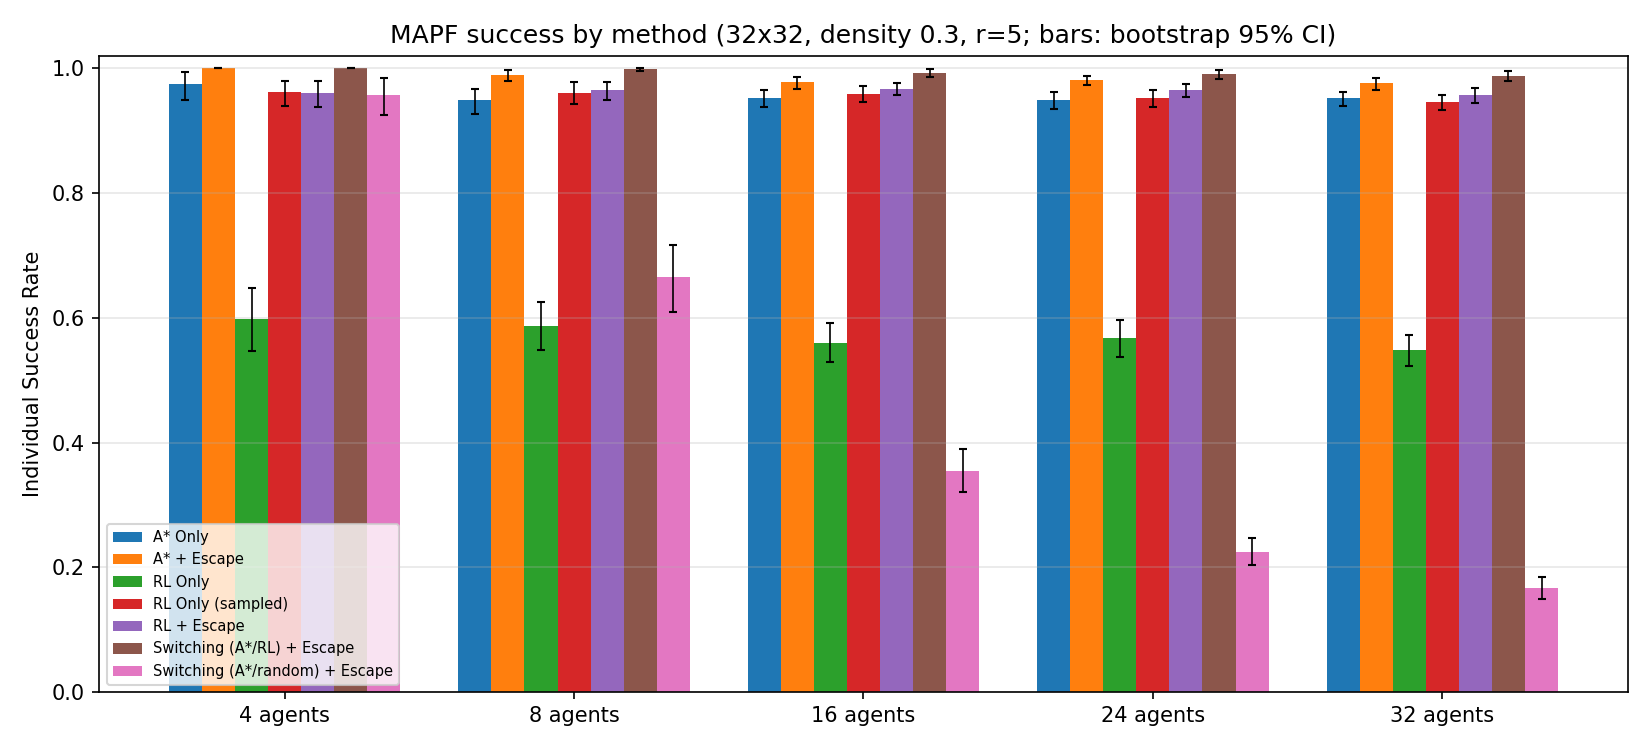

In [3]:
import json
from IPython.display import Image, display
from train import default_ckpt_dir

ckpt_dir = default_ckpt_dir()
with open(f'{ckpt_dir}/results.json') as f:
    results = json.load(f)

counts = sorted(map(int, next(iter(results['main'].values())).keys()))
header = "method".ljust(33) + "".join(f"{na:>8} ag." for na in counts)

print("Individual Success Rate (ISR):\n")
print(header)
for method, per_na in results['main'].items():
    row = method.ljust(33)
    for na in counts:
        row += f"{per_na[str(na)]['isr']:>11.1%}"
    print(row)

print("\nCooperative Success Rate (CSR, solved/episodes):\n")
print(header)
for method, per_na in results['main'].items():
    row = method.ljust(33)
    for na in counts:
        r = per_na[str(na)]
        row += f"{r['solved_n']:>7}/{r['episodes']}"
    print(row)

total = max(sum(results['mode_usage'].values()), 1)
print("\nSwitching mode usage: " + ", ".join(
    f"{k} {v/total:.1%}" for k, v in results['mode_usage'].items()))

print("\nHeadline paired tests (Switching vs A*+Escape):")
KEY = "Switching (A*/RL) + Escape vs A* + Escape"
for na, comps in results['stats'].items():
    if KEY in comps:
        s = comps[KEY]
        d = s['csr_discordant']
        print(f"  {na:>3} agents: CSR discordant {d[0]}:{d[1]}, "
              f"McNemar p={s['csr_mcnemar_p']:.4f} | "
              f"ISR diff {s['isr_mean_diff']:+.3f} p={s['isr_perm_p']:.4f}")

display(Image(f'{ckpt_dir}/results.png'))


## 8 · Zero-shot scaling to 64×64 — evaluation at the scale of the original paper

"When to Switch" (Skrynnik et al., 2023) evaluates on 64×64 maps with up to **500 agents**, while the tables above stop at 32×32 with 32 agents. Nothing ties the trained policy to the training map size — the network only ever sees a local egocentric `(4, 2r+1, 2r+1)` window — so the 32×32-trained checkpoint is evaluated here **zero-shot**, with no retraining:

* 64×64 random grids, density 0.3, r = 5, **512-step horizon** (the 32×32 tables use 256; the larger map needs a proportionally longer episode budget);
* 64 / 128 / 256 / 500 agents, all seven configurations;
* 50 paired seeds (90000–90049) — the same paired-episode protocol and the same `make_policies` / `run_episode` code path as Section 6 (run on CPU, fanned out over parallel workers; ≈5 CPU-hours total).

Results are stored in `checkpoints_64/` (`results_64.json`, `results_64.png`; `best_model.pt` is copied there too). An equivalent sequential run is:
`CKPT_DIR=checkpoints_64 MAP_SIZE=64 AGENTS=64,128,256,500 MAX_STEPS=512 EPISODES=50 SKIP_SWEEP=1 python evaluate.py`

**Caveat for comparison with the paper:** its 500-agent instances use maze and warehouse maps (MovingAI benchmark), not uniform-random grids — this section matches the paper's *scale*, not its exact benchmark maps.

Individual Success Rate (ISR):

method                                 64 ag.     128 ag.     256 ag.     500 ag.
A* Only                                94.2%      96.4%      93.8%      46.9%
A* + Escape                            98.4%      98.6%      93.8%      43.4%
RL Only                                43.1%      39.5%      34.9%      23.8%
RL Only (sampled)                      95.7%      95.3%      94.3%      87.6%
RL + Escape                            96.6%      96.5%      95.3%      90.4%
Switching (A*/RL) + Escape             99.6%      99.1%      97.7%      91.9%
Switching (A*/random) + Escape         24.2%       8.7%       6.0%       5.6%

Cooperative Success Rate (CSR, solved/episodes):

method                                 64 ag.     128 ag.     256 ag.     500 ag.
A* Only                               11/50     11/50      5/50      0/50
A* + Escape                           31/50     21/50      6/50      0/50
RL Only                                0/50      0/50      

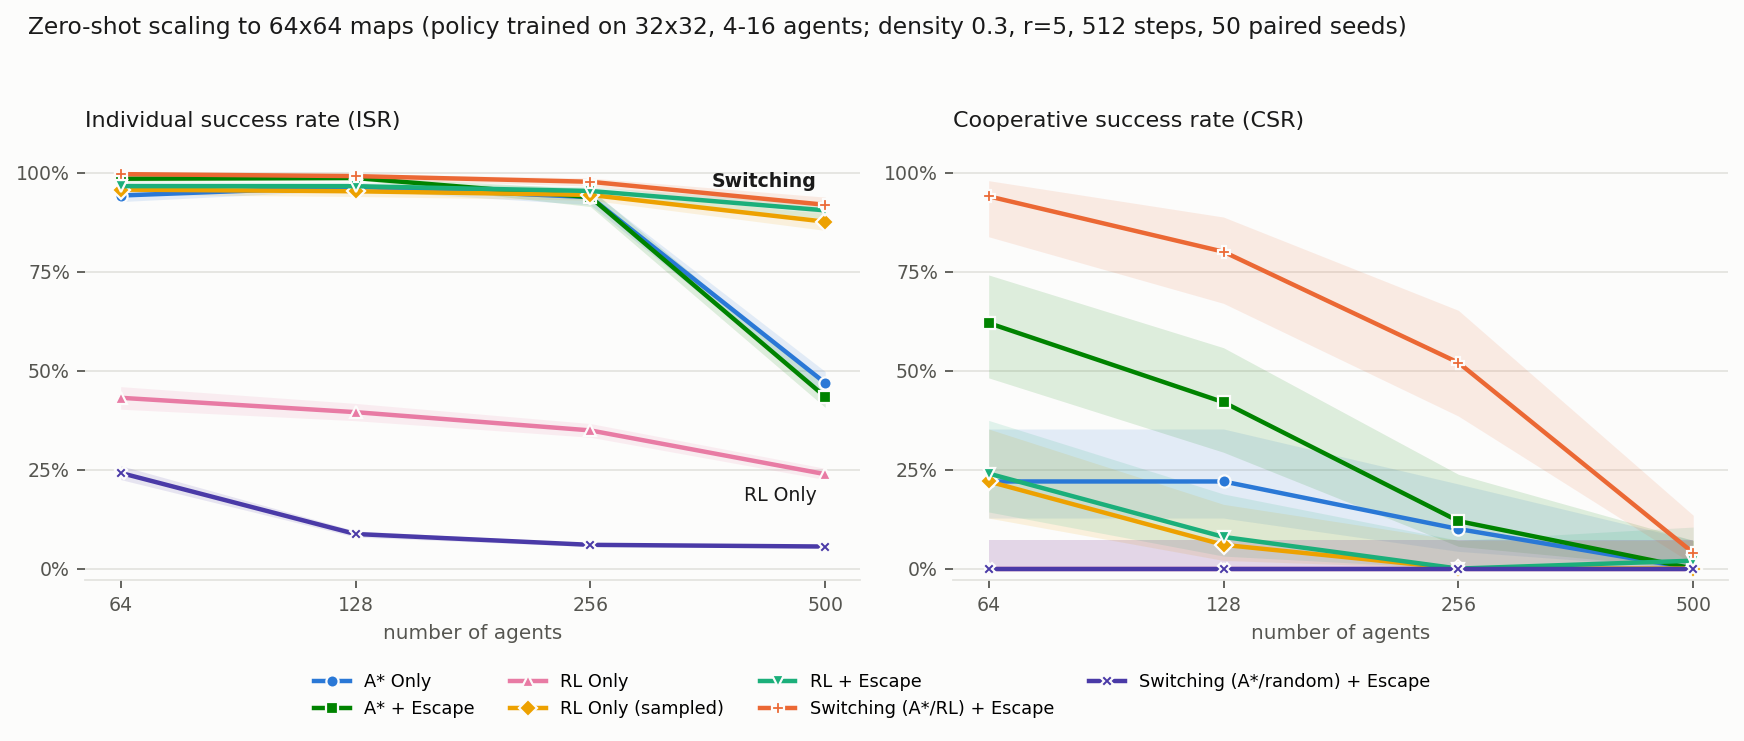

In [4]:
import json
from IPython.display import Image, display
from train import default_ckpt_dir

ckpt64_dir = default_ckpt_dir() + "_64"
with open(f"{ckpt64_dir}/results_64.json") as f:
    r64 = json.load(f)

counts = r64["config"]["agent_counts"]
header = "method".ljust(33) + "".join(f"{na:>8} ag." for na in counts)

print("Individual Success Rate (ISR):\n")
print(header)
for method, per_na in r64["results"].items():
    row = method.ljust(33)
    for na in counts:
        row += f"{per_na[str(na)]['isr']:>11.1%}"
    print(row)

print("\nCooperative Success Rate (CSR, solved/episodes):\n")
print(header)
for method, per_na in r64["results"].items():
    row = method.ljust(33)
    for na in counts:
        r = per_na[str(na)]
        row += f"{r['solved_n']:>7}/{r['episodes']}"
    print(row)

print("\nSwitching mode usage (fraction of agent-steps):")
for na in counts:
    mu = r64["mode_usage"][str(na)]
    tot = max(sum(mu.values()), 1)
    print(f"  {na:>3} agents: "
          + ", ".join(f"{k} {v / tot:.1%}" for k, v in mu.items()))

print("\nHeadline paired tests (Switching vs A*+Escape):")
KEY = "Switching (A*/RL) + Escape vs A* + Escape"
for na, comps in r64["stats"].items():
    s = comps[KEY]
    d = s["csr_discordant"]
    print(f"  {na:>3} agents: CSR discordant {d[0]}:{d[1]}, "
          f"McNemar p={s['csr_mcnemar_p']:.4f} | "
          f"ISR diff {s['isr_mean_diff']:+.3f} p={s['isr_perm_p']:.4f}")

display(Image(f"{ckpt64_dir}/results_64.png"))

**What the scaling experiment shows**

1. **Switching is the strongest configuration at every scale** — 99.6% → 91.9% ISR from 64 to 500 agents, and it is the only method that still solves a substantial share of complete instances at 256 agents (26/50 vs 6/50 for the best baseline; McNemar p < 0.0001).
2. **Pure planning collapses under congestion.** A* Only / A* + Escape hold ~94–99% ISR up to 256 agents but crash to 43–47% at 500, where ~17% of all free cells are occupied and single-agent replanning thrashes. The switcher sidesteps this by design: its A* share of agent-steps falls from 24.7% (64 agents) to 1.4% (500 agents), leaning on the learned policy exactly where planning stops working.
3. **Greedy RL locks up, sampled RL scales.** Argmax evaluation of the stochastically trained policy oscillates on long horizons (ISR ≤ 43% everywhere), while *sampling* from the same network reaches 87.6% ISR at 500 agents — the Section 6 effect, amplified by map size.
4. **CSR is a brutal metric at this scale**: with 500 agents a single failed agent fails the whole episode, so all methods are near 0/50 — the ISR gap is the meaningful signal there (+48.5 points for Switching over A* + Escape, permutation p = 0.0001).
5. This **reproduces the original paper's headline finding** at its own scale: learnable-only policies degrade sharply on the hardest instances while the hybrid stays high (their ASwitcher solves >80% at 500 agents; our switcher reaches 91.9% ISR / 97.7% at 256).

---
### What was fixed relative to the first version
1. **Reward** — the `+0.05 if target visible` bonus fired *every* step (POGEMA clamps the target into the window), making the net per-step reward positive and paying agents to wander. Replaced with distance-progress shaping toward the true goal.
2. **Observations** — the "nearby agents" channel was transposed relative to the obstacle/target channels; now taken from `Grid.get_positions` (natively aligned) with the self cell removed.
3. **Memory** — was a single local window max-ed across different world positions (meaningless superposition); now a per-agent **global** obstacle map for the planner + a visited map whose local slice feeds the network.
4. **Goal semantics** — finished agents are removed (`hide_agent`, POGEMA `on_target='finish'`) instead of remaining as permanent walls that inflate deadlocks; move order is randomized instead of index-priority.
5. **Checkpointing** — the periodic save no longer overwrites `best_model.pt`; full state (optimizer/scheduler/episode/best) is saved and restored, and evaluation is decoupled from training so a Colab disconnect can no longer erase a session's results.
6. **The paper's core mechanism** — an actual A\*↔RL↔Escape switching controller (previously absent), a real A\* (the old `astar_action` was a one-step greedy move), agent counts matching the paper (4/8/16) and an observation-radius sweep.
7. **PPO** — truncated episodes bootstrap from the final state value; multi-episode buffer with shuffled minibatches; batched per-step inference across agents (~an order of magnitude faster rollouts).